In [11]:
import numpy as np

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

try:
    from celluloid import Camera
except ImportError:
    class Camera:
        def __init__(self, fig):
            self.fig = fig

        def snap(self):
            return None

        def animate(self, *args, **kwargs):
            return None

    print("Warning: 'celluloid' is not installed. Using no-op Camera fallback.")

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("default")

from IPython.display import Image

np.random.seed(0)

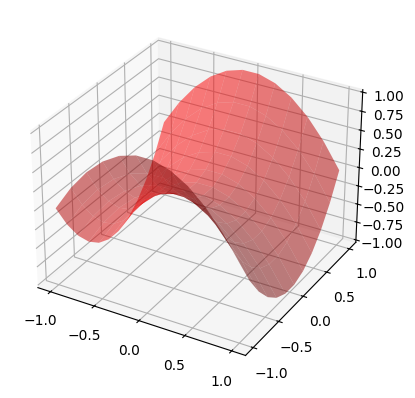

In [3]:
def generate_function(dims):
    a = 1
    b = 1

    # Hyperbolic Paraboloid
    x = np.linspace(-1, 1, dims)
    y = np.linspace(-1, 1, dims)
    X, Y = np.meshgrid(x, y)
    Z = (Y**2 / b**2) - (X**2 / a**2)

    X_t = X.flatten()
    Y_t = Y.flatten()
    Z_t = Z.flatten()
    X_t = X_t.reshape((len(X_t), 1))
    Y_t = Y_t.reshape((len(Y_t), 1))
    Z_t = Z_t.reshape((len(Z_t), 1))
    features = np.stack((X_t, Y_t), axis=1)
    labels = Z_t.reshape((len(Z_t), 1, 1))

    return X, Y, Z, features, labels


dims = 12
X, Y, Z, features, labels = generate_function(dims)

# Visualize the Hyperbolic Paraboloid
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, color="red", alpha=0.5)

In [13]:
def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [14]:
from abc import ABC, abstractmethod


class Layer(ABC):
    def __init__(self):
        self.input = None
        self.output = None
        self.weights = None
        self.bias = None

    @abstractmethod
    def forward(self, input):
        pass

    @abstractmethod
    def backward(self, output_gradient, optimizer):
        pass

In [15]:
class Dense(Layer):
    def __init__(self, input_neurons, output_neurons):
        # Random Values from Normal Distribution
        # self.weights = np.random.randn(output_neurons, input_neurons)
        # self.bias = np.random.randn(output_neurons, 1)

        # All Zeros
        # self.weights = np.zeros((output_neurons, input_neurons))
        # self.bias = np.zeros((output_neurons, 1))

        # Xavier Initialization Uniform Distribution
        limit = np.sqrt(6 / (input_neurons + output_neurons))
        self.weights = np.random.uniform(
            -limit, limit, size=(output_neurons, input_neurons)
        )
        self.bias = np.zeros((output_neurons, 1))

    def forward(self, input):
        self.input = input
        return np.matmul(self.weights, self.input) + self.bias

    def backward(self, output_gradient, optimizer):
        # Calculate gradients
        weights_gradient = np.matmul(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        # Update weights and biases
        self.weights, self.bias = optimizer.backward(
            self.weights, weights_gradient, self.bias, output_gradient
        )
        return input_gradient

In [7]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input_val):
        self.input = input_val
        return self.activation(self.input)

    def backward(self, output_gradient, optimizer):
        return np.multiply(output_gradient, self.activation_prime(self.input))

    def plot(self, x_min, x_max, points=25):
        x = np.linspace(x_min, x_max, points)
        y = self.activation(x)
        y_prime = self.activation_prime(y)

        fig, axes = plt.subplots(1, 2)
        axes[0].plot(x, y)
        axes[0].set_xlabel("X")
        axes[0].set_ylabel("Y")
        axes[0].set_title("F(X)")

        axes[1].plot(x, y_prime)
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Y")
        axes[1].set_title("F'(X)")

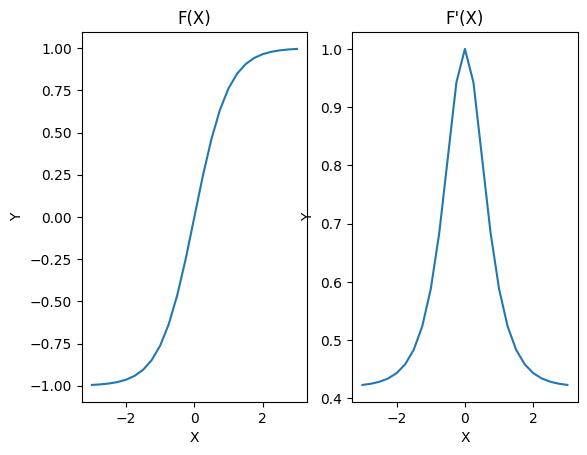

In [8]:
class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x) ** 2
        super().__init__(tanh, tanh_prime)


Tanh().plot(-3, 3)

In [9]:
class GradientDescentOptimizier:
    def __init__(self, learning_rate):
        self.learning_rate = learning_rate

    def backward(self, weights, weights_gradient, bias, output_gradient):
        weights -= self.learning_rate * weights_gradient
        bias -= self.learning_rate * output_gradient

        return weights, bias

In [16]:
import copy


def create_scatter_and_3d_plot():
    fig, ax = plt.subplots(1, 3, figsize=(16 / 9.0 * 4, 4 * 1))
    fig.suptitle("Neural Network Predictions")

    ax[0].set_xlabel("Epoch", fontweight="normal")
    ax[0].set_ylabel("Error", fontweight="normal")
    ax[0].set_title("Mean Squared Error")

    ax[1].axis("off")
    ax[2].axis("off")

    ax[2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[2].set_xlabel("X")
    ax[2].set_ylabel("Y")
    ax[2].set_zlabel("Z")
    ax[2].set_title("Function Approximation")
    ax[2].view_init(20, -35)
    ax[2].set_zlim(-1, 1)
    ax[2].axis("equal")

    camera = Camera(fig)
    return ax[0], ax[2], camera


def create_3d_and_3d_plot():
    fig, ax = plt.subplots(
        1, 2, figsize=(16 / 9.0 * 4, 4 * 1), subplot_kw={"projection": "3d"}
    )
    fig.suptitle("Neural Network Loss Landscape")

    ax[0].set_xlabel("W3_1")
    ax[0].set_ylabel("W3_2")
    ax[0].set_zlabel("MSE")
    ax[0].set_title("Mean Squared Error")
    ax[0].view_init(20, -35)
    ax[0].set_zlim(-1, 1)
    ax[0].axis("equal")

    ax[1].set_xlabel("X")
    ax[1].set_ylabel("Y")
    ax[1].set_zlabel("Z")
    ax[1].set_title("Function Approximation")
    ax[1].view_init(20, -35)
    ax[1].set_zlim(-1, 1)
    ax[1].axis("equal")

    camera = Camera(fig)
    return ax[0], ax[1], camera


def plot_3d_predictions(ax, X, Y, Z, predictions, dims):
    # Plot Neural Network Function Approximation
    # Ground truth
    ground_truth_legend = ax.plot_surface(
        X, Y, Z, color="red", alpha=0.5, label="Ground Truth"
    )

    # Neural Network Predictions
    predictions_legend = ax.scatter(
        X,
        Y,
        predictions.reshape((dims, dims)),
        color="blue",
        alpha=0.2,
        label="Prediction",
    )
    ax.plot_surface(
        X,
        Y,
        predictions.reshape((dims, dims)),
        color="blue",
        alpha=0.3,
    )
    ax.legend(
        (ground_truth_legend, predictions_legend),
        ("Ground Truth", "Predictions"),
        loc="upper left",
    )


def plot_layer_loss_landscape(
    ax0,
    network,
    target_layer_idx,
    features,
    labels,
    w1_min,
    w1_max,
    w2_min,
    w2_max,
    loss_dims,
):
    # current target layer weights
    target_layer_idx = target_layer_idx % len(network)

    w1 = network[target_layer_idx].weights[0][0]
    w2 = network[target_layer_idx].weights[0][1]
    curr_error = 0
    for x, y in zip(features, labels):
        output = x
        for layer in network:
            output = layer.forward(output)

        curr_error += mse(y, output)
    curr_error /= labels.size
    ax0.scatter([w1], [w2], [curr_error], color="red", alpha=0.4)

    target_layer = copy.deepcopy(network[target_layer_idx])
    w1_range = np.linspace(w1_min, w1_max, loss_dims)
    w2_range = np.linspace(w2_min, w2_max, loss_dims)
    w1_range, w2_range = np.meshgrid(w1_range, w2_range)
    w_range = np.stack((w1_range.flatten(), w2_range.flatten()), axis=1)

    error_range = np.array([])

    for target_layer_weight in w_range:
        target_layer_weight = target_layer_weight.reshape(1, 2)
        target_layer.weights[0, :2] = target_layer_weight[0, :2]

        error = 0
        for x, y in zip(features, labels):
            output = x
            for layer_idx, layer in enumerate(network):
                if layer_idx == target_layer_idx:
                    output = target_layer.forward(output)
                else:
                    output = layer.forward(output)

            error += mse(y, output)
        error /= labels.size
        error_range = np.append(error_range, error)

    ax0.plot_surface(
        w1_range,
        w2_range,
        error_range.reshape(loss_dims, loss_dims),
        color="blue",
        alpha=0.1,
    )


def plot_mse_and_predictions(
    ax0, ax1, idx, visible_mse, mse_idx, errors, X, Y, Z, predictions, dims
):
    ax0.plot(
        mse_idx[visible_mse][: idx + 1],
        errors[visible_mse][: idx + 1],
        color="red",
        alpha=0.5,
    )

    plot_3d_predictions(ax1, X, Y, Z, predictions, dims)


def plot_loss_landscape_and_predictions(
    ax0,
    ax1,
    network,
    target_layer_idx,
    features,
    labels,
    X,
    Y,
    Z,
    predictions,
    preds_dims,
    w1_min=-5,
    w1_max=5,
    w2_min=-5,
    w2_max=5,
    loss_dims=20,
):
    plot_3d_predictions(ax1, X, Y, Z, predictions, preds_dims)
    plot_layer_loss_landscape(
        ax0,
        network,
        target_layer_idx,
        features,
        labels,
        w1_min,
        w1_max,
        w2_min,
        w2_max,
        loss_dims,
    )


def show_epoch(epoch):
    return (
        epoch < 25
        or (epoch < 25 and epoch % 2 == 0)
        or (epoch <= 100 and epoch % 10 == 0)
        or (epoch <= 500 and epoch % 25 == 0)
        or (epoch <= 1000 and epoch % 50 == 0)
        or epoch % 250 == 0
    )

In [ ]:
mse_plot_filename = "mse_plot.png"  # or your actual file path
if os.path.exists(mse_plot_filename):
    Image(filename=mse_plot_filename)
else:
    print(f"Warning: {mse_plot_filename} not found. Please generate the plot first.")

FileNotFoundError: [Errno 2] No such file or directory: 'mse_plot.png'

In [19]:
loss_landscape_plot_filename = "loss_landscape_plot.png"  # or your actual file path